# Food Inequality Score — data-ageing simulation

The published model runs on inputs of different vintages: the class / tenure / education spine is
**Census 2021**, income is a modelled **FYE2023** estimate, and child poverty and the food economy
are **2025**. This notebook drags every input forward to **2026** with plausible year-by-year drift,
20,000 times, and reads the gap between the published score and the simulated-2026 score for
**Shoreditch** and **Brick Lane North** as an **error rate**.

Outputs, saved to `figures/`:

1. every simulated path
2. one path, both areas
3. the difference — the error rate

Self-contained: needs only `numpy` and `matplotlib`, and `areas.json` (a copy of the app's
dataset) sitting next to it.

In [1]:
import json, pathlib
import numpy as np
import matplotlib.pyplot as plt

HERE = pathlib.Path.cwd()
FIGS = HERE / "figures"; FIGS.mkdir(exist_ok=True)
AREAS = json.loads((HERE / "areas.json").read_text())

SHOREDITCH, BRICK_LANE = "E02007111", "E02000872"
N_PATHS, YEARS, STEPS, SEED = 20_000, 5, 5, 20260829
N_SHOW = 500
SH_C, BL_C = "#1d4ed8", "#c2410c"
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})

## The model

Mirror of `src/lib/indicators.ts` and `src/lib/model.ts`: each indicator is oriented so higher =
more inequality, min–max normalised across the 64 MSOAs, combined by within-domain weights and then
by domain weights. Baseline specification, 40 / 25 / 25 / 10 / 0.

In [2]:
DOMAINS = {
    "income":      (40, [("income_ahc", -1, 100)]),
    "class":       (25, [("class_de_pct", 1, 60), ("class_c2de_pct", 1, 20), ("class_ab_pct", -1, 20)]),
    "deprivation": (25, [("child_poverty_ahc_pct", 1, 50), ("social_rent_pct", 1, 25), ("private_rent_pct", 1, 25)]),
    "education":   (10, [("no_quals_pct", 1, 50), ("level4plus_pct", -1, 50)]),
    "food":        (0,  [("cultural_food_density", 1, 60), ("takeaway_density", 1, 40)]),
}
IND = [k for _, xs in DOMAINS.values() for (k, _, _) in xs]
CODES = [a["code"] for a in AREAS]
IX = {c: i for i, c in enumerate(CODES)}
i_sh, i_bl = IX[SHOREDITCH], IX[BRICK_LANE]
BASE = {k: np.array([a[k] for a in AREAS], float)
        for k in set(IND) | {"income_ahc_ci_lower", "income_ahc_ci_upper"}}

def _share(w):
    t = sum(max(0.0, v) for v in w.values()) or 1.0
    return {k: max(0.0, v) / t for k, v in w.items()}

def score(smp):
    dS = _share({d: DOMAINS[d][0] for d in DOMAINS})
    fis = 0
    for d, (_, xs) in DOMAINS.items():
        iS = _share({k: w for (k, _, w) in xs})
        sub = 0
        for k, direction, _ in xs:
            o = smp[k] * direction
            mn, mx = o.min(1, keepdims=True), o.max(1, keepdims=True)
            sub = sub + (o - mn) / np.where(mx - mn == 0, 1, mx - mn) * 100 * iS[k]
        fis = fis + sub * dS[d]
    return fis

fis0 = score({k: BASE[k][None, :] for k in IND})[0]
FIS0_SH, FIS0_BL = fis0[i_sh], fis0[i_bl]
print(f"published point   Shoreditch {FIS0_SH:.2f}   Brick Lane North {FIS0_BL:.2f}   gap {FIS0_BL - FIS0_SH:+.2f}")

published point   Shoreditch 31.02   Brick Lane North 55.47   gap +24.45


## Assumptions

Per-year drift, roughly sourced (ONS Average Weekly Earnings; ONS Private Rent Index; ONS Annual
Population Survey for occupational and qualification trends). `_study_extra` applies only to the two
study areas. `STALE` is how many years each input actually needs to be aged. Measurement uncertainty
already in the published numbers — the income confidence interval, census perturbation, and the
ward→MSOA area-apportionment of child poverty — is added as a per-path offset.

Edit and re-run all cells.

In [3]:
A = dict(
    income_growth=(0.035, 0.020),        income_study_extra=(0.040, 0.030),
    upgrade_national=(0.35, 0.15),        upgrade_study_extra=(0.60, 0.30),
    childpov_drift=(0.20, 0.30),
    social_rent_drift=(-0.20, 0.20),
    private_rent_drift=(0.15, 0.25),      private_rent_study_extra=(0.30, 0.30),
    l4_drift=(0.70, 0.25),                l4_study_extra=(0.40, 0.30),
    noqual_drift=(-0.40, 0.20),           noqual_study_extra=(-0.20, 0.20),
)
STALE = dict(income=3, grade=5, tenure=5, quals=5, childpov=1, food=0)
RNG = np.random.default_rng(SEED)

def simulate(n):
    study = np.zeros(64); study[i_sh] = study[i_bl] = 1.0
    tile = lambda v: np.tile(v, (n, 1))

    g  = RNG.normal(*A["income_growth"], (n, 1))
    gx = RNG.normal(*A["income_study_extra"], (n, 64)) * study
    u  = RNG.normal(*A["upgrade_national"], (n, 1)) + RNG.normal(*A["upgrade_study_extra"], (n, 64)) * study
    cp = RNG.normal(*A["childpov_drift"], (n, 1))
    sr = RNG.normal(*A["social_rent_drift"], (n, 1))
    pr = RNG.normal(*A["private_rent_drift"], (n, 1)) + RNG.normal(*A["private_rent_study_extra"], (n, 64)) * study
    l4 = RNG.normal(*A["l4_drift"], (n, 1)) + RNG.normal(*A["l4_study_extra"], (n, 64)) * study
    nq = RNG.normal(*A["noqual_drift"], (n, 1)) + RNG.normal(*A["noqual_study_extra"], (n, 64)) * study

    inc_sd = (BASE["income_ahc_ci_upper"] - BASE["income_ahc_ci_lower"]) / (2 * 1.645)
    inc_off = RNG.normal(0, 1, (n, 64)) * inc_sd * study
    de_off  = RNG.normal(0, 1.0, (n, 64)) * study
    cp_off  = (RNG.normal(1.0, 0.08, (n, 64)) - 1) * study
    q_off   = RNG.normal(0, 1.0, (n, 64)) * study

    sh = np.empty((n, STEPS + 1)); bl = np.empty((n, STEPS + 1))
    for s in range(STEPS + 1):
        f = s / STEPS
        smp = {
            "income_ahc": np.maximum((tile(BASE["income_ahc"]) + f * inc_off)
                                     * (1 + g) ** (f * STALE["income"]) * (1 + f * gx), 1000),
            "class_de_pct":   np.clip(tile(BASE["class_de_pct"])   - f * u * STALE["grade"] + f * de_off, 0.5, 95),
            "class_c2de_pct": np.clip(tile(BASE["class_c2de_pct"]) - f * u * STALE["grade"] + f * de_off, 0.5, 98),
            "class_ab_pct":   np.clip(tile(BASE["class_ab_pct"])   + f * u * STALE["grade"] + f * de_off, 0.5, 95),
            "child_poverty_ahc_pct": np.clip(tile(BASE["child_poverty_ahc_pct"]) * (1 + f * cp_off)
                                             + f * cp * STALE["childpov"], 0.5, 99),
            "social_rent_pct":  np.clip(tile(BASE["social_rent_pct"])  + f * sr * STALE["tenure"], 0.5, 99),
            "private_rent_pct": np.clip(tile(BASE["private_rent_pct"]) + f * pr * STALE["tenure"], 0.5, 99),
            "level4plus_pct":   np.clip(tile(BASE["level4plus_pct"]) + f * l4 * STALE["quals"] + f * q_off, 0.5, 99),
            "no_quals_pct":     np.clip(tile(BASE["no_quals_pct"])   + f * nq * STALE["quals"] + f * q_off, 0.1, 90),
            "cultural_food_density": tile(BASE["cultural_food_density"]),
            "takeaway_density":      tile(BASE["takeaway_density"]),
        }
        fis = score(smp)
        sh[:, s], bl[:, s] = fis[:, i_sh], fis[:, i_bl]
    return sh, bl

YEAR_AXIS = np.linspace(2021, 2026, STEPS + 1)
SH, BL = simulate(N_PATHS)
print(f"{N_PATHS:,} paths simulated")

20,000 paths simulated


## 1 · Every simulated path

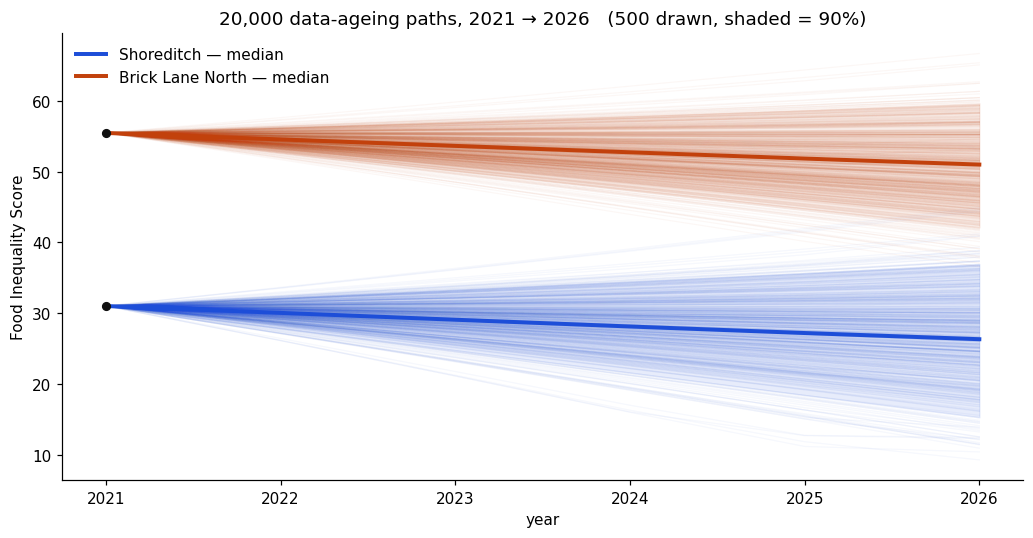

In [4]:
fig, ax = plt.subplots(figsize=(9.5, 5))
for arr, c, name in [(SH, SH_C, "Shoreditch"), (BL, BL_C, "Brick Lane North")]:
    ax.plot(YEAR_AXIS, arr[:N_SHOW].T, color=c, alpha=0.04, lw=0.8)
    ax.plot(YEAR_AXIS, np.median(arr, 0), color=c, lw=2.6, label=f"{name} — median")
    lo, hi = np.percentile(arr, [5, 95], axis=0)
    ax.fill_between(YEAR_AXIS, lo, hi, color=c, alpha=0.10)
ax.scatter([2021, 2021], [FIS0_SH, FIS0_BL], color="#111", zorder=5, s=25)
ax.set_xlabel("year"); ax.set_ylabel("Food Inequality Score")
ax.set_title(f"{N_PATHS:,} data-ageing paths, 2021 → 2026   ({N_SHOW} drawn, shaded = 90%)")
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(FIGS / "1_all_paths.png", bbox_inches="tight"); plt.show()

## 2 · One path

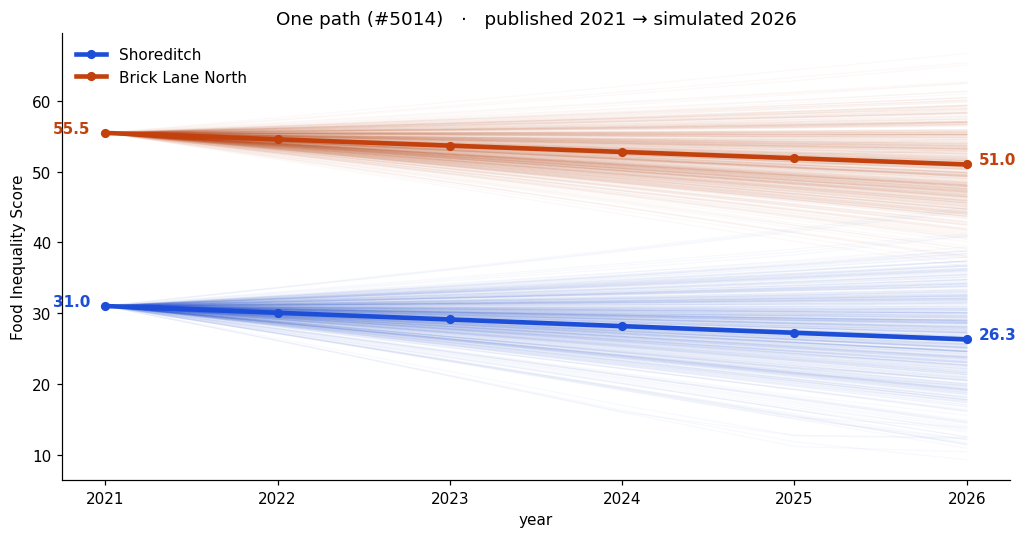

In [5]:
end_sh, end_bl = SH[:, -1], BL[:, -1]
d = ((end_sh - np.median(end_sh)) / end_sh.std()) ** 2 + ((end_bl - np.median(end_bl)) / end_bl.std()) ** 2
p = int(np.argmin(d))                      # set to any index 0..N_PATHS-1

fig, ax = plt.subplots(figsize=(9.5, 5))
for arr, c, name in [(SH, SH_C, "Shoreditch"), (BL, BL_C, "Brick Lane North")]:
    ax.plot(YEAR_AXIS, arr[:N_SHOW].T, color=c, alpha=0.03, lw=0.8)
    ax.plot(YEAR_AXIS, arr[p], color=c, lw=3, marker="o", ms=5, label=name)
    ax.annotate(f"{arr[p, 0]:.1f}", (2021, arr[p, 0]), textcoords="offset points", xytext=(-34, 0), color=c, fontweight="bold")
    ax.annotate(f"{arr[p, -1]:.1f}", (2026, arr[p, -1]), textcoords="offset points", xytext=(8, 0), color=c, fontweight="bold")
ax.set_xlabel("year"); ax.set_ylabel("Food Inequality Score")
ax.set_title(f"One path (#{p})   ·   published 2021 → simulated 2026")
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(FIGS / "2_one_path.png", bbox_inches="tight"); plt.show()

## 3 · The difference = error rate

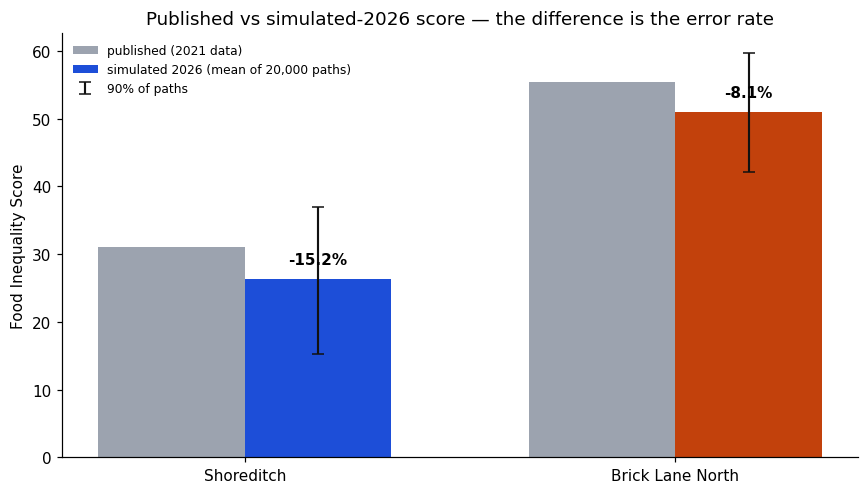

Data-ageing simulation — 20000 paths, seed 20260829

published point   Shoreditch 31.02   Brick Lane North 55.47

error rate (published 2021 -> simulated 2026)
  Shoreditch        mean -15.2%   90% CI [-50.7%, +19.1%]
  Brick Lane North  mean -8.1%   90% CI [-24.0%, +7.5%]

gap (Brick Lane North - Shoreditch) at 2026:  mean +24.66   P(Brick Lane North higher) = 99.8%



In [6]:
e_sh = 100 * (SH[:, -1] - FIS0_SH) / FIS0_SH
e_bl = 100 * (BL[:, -1] - FIS0_BL) / FIS0_BL
sim  = [SH[:, -1].mean(), BL[:, -1].mean()]
lo90 = [np.percentile(SH[:, -1], 5),  np.percentile(BL[:, -1], 5)]
hi90 = [np.percentile(SH[:, -1], 95), np.percentile(BL[:, -1], 95)]

fig, ax = plt.subplots(figsize=(8, 4.6))
x, w = np.arange(2), 0.34
ax.bar(x - w/2, [FIS0_SH, FIS0_BL], w, color="#9ca3af", label="published (2021 data)")
ax.bar(x + w/2, sim, w, color=[SH_C, BL_C], label=f"simulated 2026 (mean of {N_PATHS:,} paths)")
ax.errorbar(x + w/2, sim,
            yerr=[[sim[0]-lo90[0], sim[1]-lo90[1]], [hi90[0]-sim[0], hi90[1]-sim[1]]],
            fmt="none", ecolor="#111", capsize=4, lw=1.4, label="90% of paths")
for i, (sv, ev) in enumerate(zip(sim, [e_sh.mean(), e_bl.mean()])):
    ax.text(i + w/2, sv + 2.2, f"{ev:+.1f}%", ha="center", fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(["Shoreditch", "Brick Lane North"])
ax.set_ylabel("Food Inequality Score")
ax.set_title("Published vs simulated-2026 score — the difference is the error rate")
ax.legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout(); fig.savefig(FIGS / "3_error_rate.png", bbox_inches="tight"); plt.show()

summary = (
    f"Data-ageing simulation — {N_PATHS} paths, seed {SEED}\n\n"
    f"published point   Shoreditch {FIS0_SH:.2f}   Brick Lane North {FIS0_BL:.2f}\n\n"
    f"error rate (published 2021 -> simulated 2026)\n"
    f"  Shoreditch        mean {e_sh.mean():+.1f}%   90% CI [{np.percentile(e_sh,5):+.1f}%, {np.percentile(e_sh,95):+.1f}%]\n"
    f"  Brick Lane North  mean {e_bl.mean():+.1f}%   90% CI [{np.percentile(e_bl,5):+.1f}%, {np.percentile(e_bl,95):+.1f}%]\n\n"
    f"gap (Brick Lane North - Shoreditch) at 2026:  mean {(BL[:,-1]-SH[:,-1]).mean():+.2f}   "
    f"P(Brick Lane North higher) = {100*np.mean(BL[:,-1] > SH[:,-1]):.1f}%\n"
)
(HERE / "summary.txt").write_text(summary)
print(summary)

## Reading it

Quote the **mean error rate across all paths** (the labels on figure 3), with the 90% CI as the
band. Bringing the 2021-anchored data to 2026 makes both areas look **less** food-unequal —
Shoreditch more so — because the drift lowers the DE share and raises income and graduate share.
The comparison the study rests on survives: Brick Lane North still scores higher than Shoreditch in
~100% of paths.

Set `p` in the cell above §2 to inspect a different path; edit `A` and `STALE` and re-run all.